## Ri₀ control on early entrainment

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import mixing_c_map, label_map

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
folder = "../../data/datafiles"

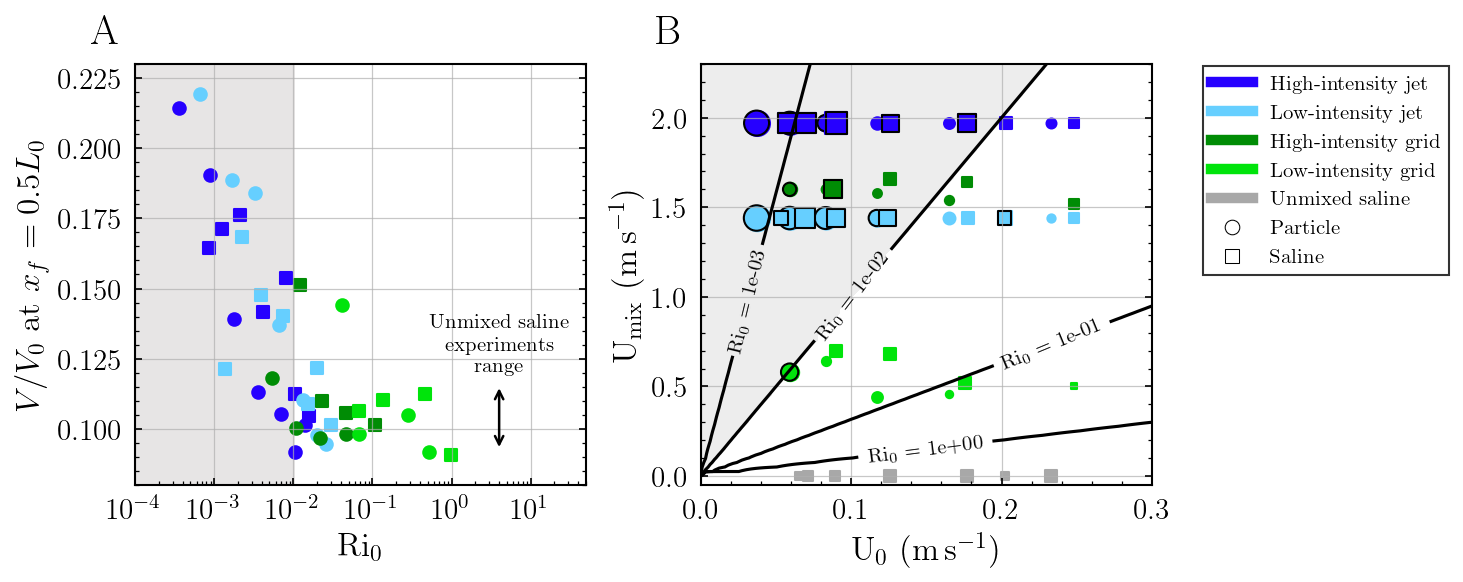

In [11]:
# --- Constants ---
H = 0.25  # characteristic current depth (m)
L0_VAL = 0.5  # normalised front position at which entrainment is evaluated (x/L0)
RI_CUT = 0.01  # Ri threshold below which mixing is vigorous (shaded region)
S_MIN, S_MAX = 0.08, 0.22  # area ratio range for marker size scaling

# --- Ri parameter space grid ---
u0 = np.linspace(0, 0.3, 100)
v_mix = np.linspace(0, 2.5, 100)
U0, V_mix = np.meshgrid(u0, v_mix)
Ri_grid = U0**2 / (V_mix**2 + 1e-6)  # add small epsilon to avoid division by zero

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# --- Panel 1: Ri contours in (g', U_mix) space ---
# Shade low-Ri region where vigorous mixing is expected
ax[1].contourf(
    U0, V_mix, Ri_grid < RI_CUT, levels=[0.5, 1], colors=["#dddddd"], alpha=0.5
)

# Overlay Ri isolines
CS = ax[1].contour(U0, V_mix, Ri_grid, levels=np.logspace(-3, 0, 4), colors="k")
# choose positions (x, y) in data coordinates
manual_locations = [(0.15, 0.1), (0.23, 0.8), (0.12, 0.9), (0.02, 1)]
ax[1].clabel(CS, inline=True, fmt="Ri$_0$ = %.0e", manual=manual_locations)
ax[1].set(
    xlabel="U$_0$ (m\\,s$^{-1}$)",
    ylabel="U$_{\\mathrm{mix}}$ (m\\,s$^{-1}$)",
    ylim=[-0.05, 2.3],
    xlim=[0, 0.3],
)

# --- Loop over experiments ---
nm_areas = []  # collect no-mixing (saline, mixing=none) area ratios

for _, row in metadata.iterrows():
    data = np.load(f"{folder}/{row.exp_code}.npy", allow_pickle=True).item()
    areas = np.abs(data["area_m2"])
    fronts = np.abs(data["front_m"]) / l0

    # Reduced gravity and Richardson number
    g_prime = 9.81 * row.del_rho / 998.2
    ri = (g_prime * H) / (row["U_mix"] ** 2)

    # Area ratio at x = L0/2 (early-time entrainment proxy)
    idx_l0 = np.argmin(np.abs(fronts - L0_VAL))
    area_at_l0 = areas[idx_l0] / (l0 * H)

    # Marker style: circle = particle, square = saline
    c = mixing_c_map.get(row["mixing"])
    m = "o" if row.type == "part" else "s"

    # Scale marker size linearly with normalised area ratio
    s = (area_at_l0 - S_MIN) / (S_MAX - S_MIN) * 150

    u_mix = row["U_mix"]
    if row.mixing == "none":
        nm_areas.append(area_at_l0)
        u_mix = 0  # no active mixing for baseline experiments

    # Panel 0: area ratio vs Ri_0
    ax[0].axvspan(0, RI_CUT, color="#e7e5e5", alpha=0.1, zorder=0)
    ax[0].scatter(row.Ri_0, area_at_l0, marker=m, c=c)

    # Panel 1: experiments overlaid on Ri parameter space
    ax[1].scatter(row.u_0, u_mix, marker=m, c=c, s=s)

    # Outline experiments with elevated early entrainment (area ratio above baseline)
    if area_at_l0 > 0.116:
        ax[1].scatter(
            row.u_0,
            u_mix,
            marker=m,
            s=s,
            edgecolor="k",
            facecolor="none",
            linewidth=1,
        )

# --- Panel 0 formatting ---
ax[0].set(
    xscale="log",
    xlabel="Ri$_0$",
    ylabel="$V/V_0$ at $x_f=0.5L_0$",
    xlim=[0.0001, 50],
    ylim=[0.08, 0.23],
)


legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=5,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in mixing_c_map.items()
    ],
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]
ax[0].annotate(
    "",
    xy=(4, 0.116),
    xytext=(4, 0.092),
    arrowprops=dict(arrowstyle="<->", color="k", lw=1.2),
)

ax[0].text(
    4, 0.13, "Unmixed saline\nexperiments\nrange", fontsize=10, va="center", ha="center"
)

# ============== Labels ==============
for axis, label in zip(ax, ["A", "B"]):
    # axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

fig.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1, 0.89),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("../figures/figure_14.png", bbox_inches="tight", dpi=300)
plt.show()